In [7]:
import numpy as np
import matplotlib.pyplot as plt
import construct as ut
import os
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from IndividualParcellation.global_config import *
import OptimalBattery.estimate as es
import OptimalBattery.util as ut
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot
import matplotlib.pyplot as plt
import numpy as np
from Functional_Fusion.dataset import DataSetLanguage
from matplotlib.colors import ListedColormap
from scipy.stats import ttest_rel
import nitools as nt
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import sem  
import pandas as pd 
from matplotlib.patches import Patch




In [8]:
# define atlas and dirs
space = 'SUIT3'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

# define constants for this specific analysis (language localizer)

############## Load data ##############
subj = ['sub-02','sub-04','sub-06','sub-07','sub-08','sub-09','sub-10','sub-12','sub-13','sub-14','sub-15','sub-16','sub-17','sub-18','sub-19']
lang_dataset = DataSetLanguage(f'{func_fus_dir}/Language')

data_all,info_all  =lang_dataset.get_data(space=space,ses_id='ses-localizer_cond',type='CondAll',subj=subj)
data_all[np.isnan(data_all)] = 0

# remove any spaces in the taskName column..
info_all['taskName'] = info_all['taskName'].str.replace(' ', '')

data_all = ut.recenter_fmri_data(data_all,info_all,task_column_name='taskName',center_condition='rest')

task_names_s1  = info_all['taskName'].unique()
#####################################


# Parcellation (nettekoven)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-SUIT'
model_type = 'atl-NettekovenSym32'
model_name = f'{atlas_dir}/{model_type}_space-SUIT_probseg.nii'
parcelation_32 = atlas.read_data(model_name)
# make argmax of the parcellation
parcelation_32 = np.argmax(parcelation_32,axis=0)
labels = nt.read_lut(f'{atlas_dir}/{model_type}.lut')[2][1:]

In [9]:
parcelation_32.shape

(6918,)

In [10]:
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_all = pt.tensor(data_all, dtype=pt.float32, device=device)
parcelation = pt.tensor(parcelation_32, dtype=pt.float32, device=device)


In [15]:
full_vs_train = es.estimate_Vs(data_all,parcellation=parcelation,ROI_mask= None)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

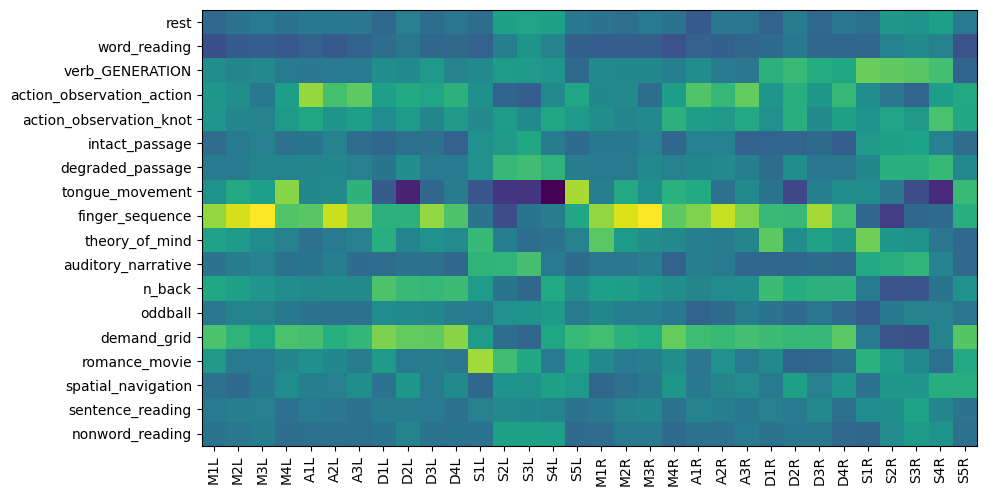

In [16]:
plt.figure(figsize=(10, 10))
plt.imshow(full_vs_train.cpu().numpy())
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks = range(len(task_names_s1)), labels=task_names_s1)
plt.show()